# Reto 2 · Fenotipos de secuelas en CIBERESUCICOVID (3, 6 y 12 meses)

**Notebook 03.** Clustering de fenotipos **solo en CIBERESUCICOVID**, la cohorte grande con un único cuaderno de recogida, y comparación posterior con POSTCOVID-Lleida y TENACITY.

| | |
|---|---|
| Definición | **Función pulmonar** (DLCO, FVC) y **síntomas** (astenia/fatiga, resolución clínica), con peso igual por dominio |
| Horizontes (acumulados) | H3 = visita de 3 meses; H6 = 3 + 6 meses (con el cambio de DLCO y FVC); H12 = 3 + 6 + 12 meses. A los 12 meses CIBERESUCICOVID **no** recoge síntomas: se usan los de 3 y 6 meses |
| Inclusión | Superviviente, sin inconsistencias, cumplimentación ≥ 50 %, y **función y síntomas en la última visita** (a 12 meses, solo función) |
| Descripción (no define) | Reingresos, urgencias, complicaciones, hallazgos del TAC, FEV1, edad, sexo, gravedad y comorbilidad |
| Comparación | Lleida y TENACITY **solo comparten DLCO y FVC**. Su «astenia» no equivale a la «astenia/fatiga» de CIBERESUCICOVID: prevalencias del 2 %, 25 % y 58 %. Los fenotipos se transfieren con la función pulmonar y se describen con lo que esas cohortes sí tienen: HADS, mMRC, PM6M |

**Método.**
- Distancia de Gower: numéricas normalizadas por un rango fijo (P2,5–P97,5 de CIBERESUCICOVID, idéntico en todas las cohortes), binarias por coincidencia, sin imputar.
- PAM, con k elegido frente a una prueba nula de permutación.
- Estabilidad bootstrap y estabilidad entre centros.
- Replicación: transferencia al medoide frente a clustering nativo, con emparejamiento húngaro.

> **Privacidad.** Solo agregados; celdas < 10 suprimidas. Etiquetas por paciente en `Datos limpios/fenotipos.parquet`.

## 0 · Entorno y contrato

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import adjusted_rand_score

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
from src import carga, fenotipado as F, pasaporte as P, privacidad

cfg = carga.cargar_config()
FC = cfg["fenotipado"]
DESC = FC["descubre"]
SEMILLA = cfg["semilla"]
N_MIN = cfg["privacidad"]["n_minimo_celda"]
COLOR = cfg["colores_registro"]
ETQ = {"CIBERESUCICOVID": "CIBERESUCICOVID", "POSTCOVID_LLEIDA": "POSTCOVID-Lleida", "TENACITY": "TENACITY"}
HORIZONTES = list(FC["horizontes"])
KS = list(range(FC["k_rango"][0], FC["k_rango"][1] + 1))
DATOS = carga.RAIZ / cfg["rutas"]["procesados"]
FIG = RAIZ / cfg["rutas"]["figuras"]; FIG.mkdir(parents=True, exist_ok=True)
TAB = RAIZ / cfg["rutas"]["tablas"]; TAB.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 11.5,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 220)


def nota(fig, texto: str) -> None:
    fig.text(0.01, -0.01, texto, fontsize=8.5, color="0.35", va="top", ha="left")


def guardar(fig, nombre: str) -> None:
    fig.savefig(FIG / f"{nombre}.png", bbox_inches="tight", dpi=150)


def ic_wilson(k: int, n: int, z: float = 1.96) -> tuple[float, float]:
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    c = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    m = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return (100 * (c - m), 100 * (c + m))


def nombre_f(c: int) -> str:
    return f"F{c + 1}"


def pct_seguro(serie: pd.Series) -> float:
    """% de 1 en una serie 0/1 (NaN si N < N_MIN o si hay entre 1 y N_MIN−1 casos)."""
    s = serie.dropna(); k = int(s.sum())
    return 100 * k / len(s) if len(s) >= N_MIN and (k == 0 or k >= N_MIN) else np.nan

In [2]:
pd.DataFrame([
    ("Visitas (días, tolerancia)", {v: d["ventana"] for v, d in FC["visitas"].items()}),
    ("Horizontes", FC["horizontes"]),
    ("Dominios de definición", FC["dominios"]),
    ("Rango de normalización", FC["rango_gower"]),
    ("Elección de k", f"k en {KS}: mayor (silueta real − media nula) entre los que superan el p95 ({FC['n_permutaciones']} permutaciones)"),
    ("Estable", f"Jaccard bootstrap ({FC['n_bootstrap']}): ≥ 0,75 estable; 0,5–0,75 patrón; < 0,5 se disuelve"),
    ("Viaja", "ARI transferidas frente a nativas con IC 95 % que excluye 0; Jaccard por par ≥ 0,5"),
    ("Variables compartidas para comparar", FC["compartidas"]),
], columns=["criterio", "valor"]).set_index("criterio")

,valor
criterio,
"Visitas (días, tolerancia)","{'M3': [30, 150], 'M6': [120, 270], 'A1': [240..."
Horizontes,"{'H3': ['M3'], 'H6': ['M3', 'M6'], 'H12': ['M3..."
Dominios de definición,"{'funcion': ['dlco', 'fvc'], 'sintomas': ['fat..."
Rango de normalización,"{'dlco': [40, 110], 'fvc': [55, 125], 'resoluc..."
Elección de k,"k en [2, 3, 4, 5, 6]: mayor (silueta real − me..."
Estable,"Jaccard bootstrap (200): ≥ 0,75 estable; 0,5–0..."
Viaja,ARI transferidas frente a nativas con IC 95 % ...
Variables compartidas para comparar,"[dlco, fvc]"


Criterios fijados **antes** de ver los resultados (`config.yaml`). Un fenotipo que no los cumple se presenta igualmente, como no replicado o inestable.

## 1 · Pacientes por horizonte

In [3]:
pacientes = pd.read_parquet(DATOS / "pacientes.parquet")
medidas = pd.read_parquet(DATOS / "medidas.parquet")
cohortes = [DESC, *FC["replica"]]
tablas_var = {(h, c): F.construir_variables(medidas, pacientes, cfg, h, c) for h in HORIZONTES for c in cohortes}

n_tabla = pd.DataFrame({h: {ETQ[c]: len(tablas_var[(h, c)][0]) for c in cohortes} for h in HORIZONTES})
for h in HORIZONTES:
    limite = FC["visitas"][FC["horizontes"][h][-1]]["ventana"][1]
    assert tablas_var[(h, DESC)][0]["dias_max"].max() <= limite, "fuga de datos futuros"
print("Comprobado: ninguna variable usa datos posteriores a su horizonte.")
print("Variables por horizonte:", {h: tablas_var[(h, DESC)][1] for h in HORIZONTES})
privacidad.suprimir_celdas(n_tabla, N_MIN, HORIZONTES)

Comprobado: ninguna variable usa datos posteriores a su horizonte.
Variables por horizonte: {'H3': ['dlco_M3', 'fvc_M3', 'fatiga_M3', 'resolucion_M3'], 'H6': ['dlco_M3', 'dlco_M6', 'dlco_cambio', 'fvc_M3', 'fvc_M6', 'fvc_cambio', 'fatiga_M3', 'fatiga_M6', 'resolucion_M3', 'resolucion_M6'], 'H12': ['dlco_M3', 'dlco_M6', 'dlco_A1', 'dlco_cambio', 'fvc_M3', 'fvc_M6', 'fvc_A1', 'fvc_cambio', 'fatiga_M3', 'fatiga_M6', 'resolucion_M3', 'resolucion_M6']}


,H3,H6,H12
CIBERESUCICOVID,913,799,566
POSTCOVID-Lleida,464,384,301
TENACITY,154,60,66


In [4]:
cobertura = pd.concat({h: tablas_var[(h, DESC)][0][tablas_var[(h, DESC)][1]].notna().mean().mul(100).round(0)
                       for h in HORIZONTES}, axis=1)
print(f"% de pacientes de {DESC} con dato en cada variable (Gower usa los pares disponibles; no se imputa):")
cobertura

% de pacientes de CIBERESUCICOVID con dato en cada variable (Gower usa los pares disponibles; no se imputa):


,H3,H6,H12
dlco_M3,81.0,32.0,37.0
fvc_M3,98.0,38.0,46.0
fatiga_M3,100.0,88.0,86.0
resolucion_M3,100.0,89.0,86.0
dlco_M6,NaN,80.0,40.0
dlco_cambio,NaN,29.0,55.0
fvc_M6,NaN,98.0,47.0
fvc_cambio,NaN,37.0,69.0
fatiga_M6,NaN,99.0,87.0
resolucion_M6,NaN,100.0,87.0


## 2 · Los tres clusterings

In [5]:
def ejecutar(h: str, k_forzado: int | None = None, columnas: list[str] | None = None, filtro=None,
             n_perm: int | None = None, n_boot: int | None = None, replicar: bool = True) -> dict:
    """Clustering de un horizonte en CIBERESUCICOVID + estabilidad + replicación."""
    t, cols = tablas_var[(h, DESC)]
    cols = columnas or cols
    if filtro is not None:
        t = t[filtro(t)]
    t = t[t[cols].notna().any(axis=1)]
    X = t[cols].to_numpy(float)
    R, w, cat = F.parametros_gower(cols, cfg)
    D = F.gower(X, None, R, w, cat)
    nulo = F.seleccion_k_nulo(X, R, w, cat, KS, n_perm or FC["n_permutaciones"], SEMILLA, D)
    k, estructura = (k_forzado, bool(nulo.set_index("k").loc[k_forzado, "supera_p95"])) if k_forzado else F.elegir_k(nulo)
    lab, med = F.pam(D, k, SEMILLA)
    ultima = FC["horizontes"][h][-1]
    ref = t[f"dlco_{ultima}"] if f"dlco_{ultima}" in t else t[[c for c in cols if c.startswith("dlco")]].mean(axis=1)
    lab, med = F.ordenar_por_dlco(lab, med, ref.to_numpy(float))
    r = {"h": h, "cols": cols, "R": R, "w": w, "cat": cat, "desc": t, "X": X, "D": D, "nulo": nulo, "k": k,
         "estructura": estructura, "lab": lab, "med": med, "silueta": F.silueta(D, lab),
         "estab": F.estabilidad_bootstrap(D, lab, k, n_boot or FC["n_bootstrap"], SEMILLA),
         "centros": F.estabilidad_centros(D, lab, t["centro_id"], k, FC["min_pacientes_centro"], SEMILLA),
         "replicas": {}}
    # ¿Se reconocen los fenotipos solo con las variables compartidas? (asignación al medoide sin síntomas)
    solo_comp = np.array([c.rsplit("_", 1)[0] in FC["compartidas"] for c in cols])
    Xc = np.where(solo_comp, X, np.nan)
    r["ari_solo_compartidas"] = adjusted_rand_score(lab, F.asignar_medoides(F.gower(Xc, X[med], R, w, cat)))
    if replicar:
        for rep in FC["replica"]:
            tr = tablas_var[(h, rep)][0]
            if len(tr) < 2 * k:
                continue
            out = P.replicar(X, med, tr.reindex(columns=cols).to_numpy(float), R, w, cat, k,
                             n_boot or FC["n_bootstrap"], SEMILLA)
            out["datos"] = tr
            out["dif"] = P.diferencias_perfil(t, lab, tr.reindex(columns=cols), out["transferidas"],
                                              [c for c in cols if solo_comp[cols.index(c)]], k)
            r["replicas"][rep] = out
    return r


resultados = {h: ejecutar(h) for h in HORIZONTES}
for h, r in resultados.items():
    print(f"{h}: N = {len(r['desc'])}, k = {r['k']}, estructura frente al nulo = {'sí' if r['estructura'] else 'NO'}, "
          f"silueta = {r['silueta']:.2f}, ARI reconociendo solo con DLCO/FVC = {r['ari_solo_compartidas']:.2f}")

H3: N = 913, k = 3, estructura frente al nulo = sí, silueta = 0.58, ARI reconociendo solo con DLCO/FVC = 0.01
H6: N = 799, k = 3, estructura frente al nulo = sí, silueta = 0.50, ARI reconociendo solo con DLCO/FVC = 0.00
H12: N = 566, k = 3, estructura frente al nulo = sí, silueta = 0.37, ARI reconociendo solo con DLCO/FVC = 0.04


## 3 · Elección de k: silueta real frente a la nula

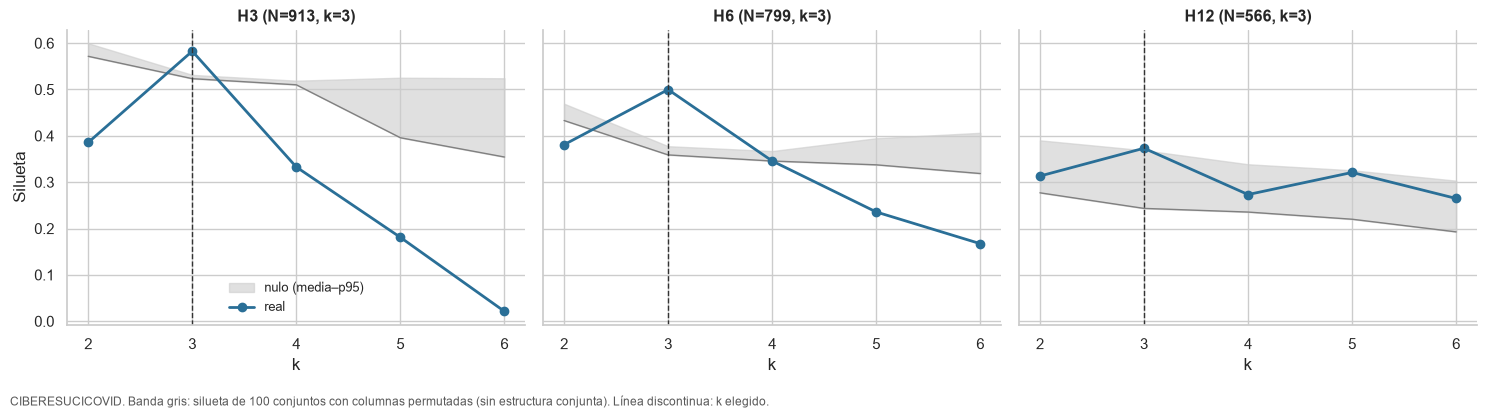

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, h in zip(axes, HORIZONTES):
    r = resultados[h]; nl = r["nulo"]
    ax.fill_between(nl["k"], nl["nulo_media"], nl["nulo_p95"], color="0.8", alpha=0.6, label="nulo (media–p95)")
    ax.plot(nl["k"], nl["nulo_media"], color="0.5", lw=1)
    ax.plot(nl["k"], nl["silueta_real"], "o-", color=COLOR[DESC], lw=2, label="real")
    ax.axvline(r["k"], color="0.2", ls="--", lw=1)
    ax.set_title(f"{h} (N={len(r['desc'])}, k={r['k']})"); ax.set_xticks(KS); ax.set_xlabel("k")
axes[0].set_ylabel("Silueta"); axes[0].legend(frameon=False, fontsize=9)
nota(fig, f"{DESC}. Banda gris: silueta de {FC['n_permutaciones']} conjuntos con columnas permutadas (sin estructura conjunta). "
          "Línea discontinua: k elegido.")
plt.tight_layout(); guardar(fig, "03_eleccion_k"); plt.show()

## 4 · Perfiles de los fenotipos

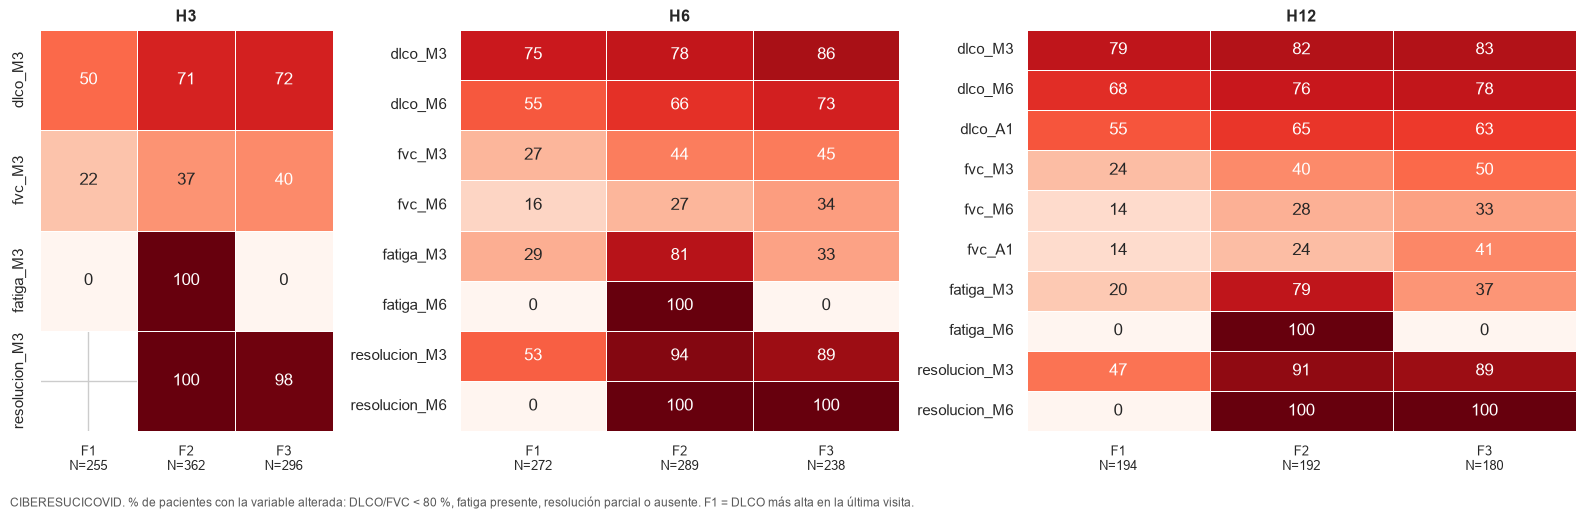

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), gridspec_kw={"width_ratios": [0.8, 1.2, 1.5]})
for ax, h in zip(axes, HORIZONTES):
    r = resultados[h]
    pct, n_alt = F.porcentaje_alterado(r["desc"], r["cols"], r["lab"], cfg)
    tam = pd.Series(r["lab"]).value_counts().sort_index()
    oculta = (n_alt > 0) & (n_alt < N_MIN)
    oculta.loc[:, tam[tam < N_MIN].index] = True
    etiquetas = pct.round(0).astype("Int64").astype(str).mask(oculta, "<10")
    visible = pct.mask(oculta)
    visible.columns = [f"{nombre_f(c)}\nN={tam[c] if tam[c] >= N_MIN else '<10'}" for c in pct.columns]
    sns.heatmap(visible, annot=etiquetas.values, fmt="", cmap="Reds", vmin=0, vmax=100, cbar=False, ax=ax, linewidths=0.5)
    ax.set_title(h); ax.set_ylabel(""); ax.tick_params(axis="x", rotation=0, labelsize=9)
nota(fig, f"{DESC}. % de pacientes con la variable alterada: DLCO/FVC < 80 %, fatiga presente, resolución parcial o ausente. "
          "F1 = DLCO más alta en la última visita.")
plt.tight_layout(); guardar(fig, "03_perfiles"); plt.show()

In [8]:
filas = []
for h, r in resultados.items():
    med_ = r["desc"][r["cols"]].groupby(r["lab"]).median()
    for c, fila in med_.iterrows():
        if (r["lab"] == c).sum() >= N_MIN:
            filas.append({"horizonte": h, "fenotipo": nombre_f(c), "N": int((r["lab"] == c).sum()), **fila.round(1).to_dict()})
medianas = pd.DataFrame(filas).set_index(["horizonte", "fenotipo"])
medianas.to_csv(TAB / "03_medianas_fenotipos.csv")
print("Medianas por fenotipo (fatiga: 0/1; resolución: 0 = total, 1 = parcial, 2 = no):")
medianas

Medianas por fenotipo (fatiga: 0/1; resolución: 0 = total, 1 = parcial, 2 = no):


N  dlco_M3  fvc_M3  fatiga_M3  resolucion_M3  dlco_M6  dlco_cambio  fvc_M6  fvc_cambio  fatiga_M6  resolucion_M6  dlco_A1  fvc_A1
horizonte fenotipo                                                                                                                                     
H3        F1        255     79.2    93.0        0.0            0.0      NaN          NaN     NaN         NaN        NaN            NaN      NaN     NaN
          F2        362     69.6    85.6        1.0            1.0      NaN          NaN     NaN         NaN        NaN            NaN      NaN     NaN
          F3        296     67.0    84.0        0.0            1.0      NaN          NaN     NaN         NaN        NaN            NaN      NaN     NaN
H6        F1        272     67.0    91.2        0.0            1.0     78.0          5.9    93.0         3.0        0.0            0.0      NaN     NaN
          F2        289     65.0    82.0        1.0            1.0     71.0          4.5    88.0         6.0        1.0            1.0      NaN     NaN
          F3        238     63.0    84.0        0.0            1.0     70.0          4.5    87.0         5.8        0.0            1.0      NaN     NaN
H12       F1        194     69.0    90.0        0.0            0.0     71.5          8.0    91.0         5.0        0.0            0.0     78.0    94.0
          F2        192     67.0    85.6        1.0            1.0     68.0          2.1    87.0         4.0        1.0            1.0     76.0    93.0
          F3        180     65.0    79.5        0.0            1.0     67.0          6.0    85.0         4.0        0.0            1.0     74.0    83.0

### Fichas: descripción con variables que no definen el fenotipo

Las fichas usan:
- **Eventos:** reingreso, urgencias y complicaciones en alguna visita hasta el horizonte.
- **Imagen:** hallazgo del TAC en alguna visita, solo entre quienes se hicieron TAC (son TAC selectivos).
- **FEV1** en la última visita.
- **Variables del ingreso.**

In [9]:
def ficha(h: str, cohorte: str, datos: pd.DataFrame, etiquetas: np.ndarray, k: int) -> pd.DataFrame:
    visitas = FC["horizontes"][h]
    p = pacientes.set_index("subject_id").reindex(datos.index)
    desc_cfg = FC["descripcion"]
    seguimiento = {}
    if cohorte == DESC:
        for v in desc_cfg["eventos"] + desc_cfg["imagen"]:
            seguimiento[v] = F.estado_hasta(medidas, cfg, cohorte, datos.index, v, visitas, "alguna")
        for v in desc_cfg["otras"]:
            seguimiento[v] = F.estado_hasta(medidas, cfg, cohorte, datos.index, v, visitas, "ultima")
    else:
        for v in desc_cfg["replica"]:
            seguimiento[v] = F.estado_hasta(medidas, cfg, cohorte, datos.index, v, visitas, "ultima")
    filas = {}
    for c in range(k):
        s = etiquetas == c
        sub = p[s]
        col = {"N": int(s.sum())}
        if s.sum() >= N_MIN:
            col["Edad ≥ 65 (%)"] = pct_seguro(sub["grupo_edad"].isin(["65-74", ">=75"]).astype(float).where(sub["grupo_edad"].notna()))
            col["Mujeres (%)"] = pct_seguro((sub["sexo"] == 1).astype(float).where(sub["sexo"].notna()))
            col["Estancia (mediana, días)"] = sub["estancia_hosp_dias"].median()
            for v in desc_cfg["ingreso_binarias"]:
                col[f"{v.replace('nu_', '')} (%)"] = pct_seguro(sub[v])
            for v, serie in seguimiento.items():
                col[f"{v} (% sí / alterado)"] = pct_seguro(serie[s])
        filas[nombre_f(c)] = col
    return pd.DataFrame(filas).round(1)


fichas = {(h, DESC): ficha(h, DESC, r["desc"], r["lab"], r["k"]) for h, r in resultados.items()}
for h, r in resultados.items():
    print(f"\n=== {h} · {DESC} ===")
    display(fichas[(h, DESC)].dropna(how="all"))


=== H3 · CIBERESUCICOVID ===


,F1,F2,F3
N,255.0,362.0,296.0
Edad ≥ 65 (%),29.8,31.8,31.1
Mujeres (%),17.7,34.0,30.7
"Estancia (mediana, días)",21.0,27.0,30.0
ingreso_uci (%),100.0,100.0,100.0
traqueo (%),22.4,32.3,37.3
hta (%),40.8,45.6,43.6
diabetes (%),15.7,18.0,11.5
epoc (%),3.9,6.4,NaN
card_cronica (%),11.8,10.2,9.5



=== H6 · CIBERESUCICOVID ===


,F1,F2,F3
N,272.0,289.0,238.0
Edad ≥ 65 (%),33.1,38.1,35.7
Mujeres (%),23.2,38.1,26.9
"Estancia (mediana, días)",25.0,31.0,37.0
ingreso_uci (%),100.0,100.0,100.0
traqueo (%),25.5,34.3,46.2
hta (%),38.2,47.8,47.9
diabetes (%),17.3,23.9,20.6
epoc (%),5.9,4.2,NaN
card_cronica (%),9.6,10.7,12.6



=== H12 · CIBERESUCICOVID ===


,F1,F2,F3
N,194.0,192.0,180.0
Edad ≥ 65 (%),36.6,38.0,41.1
Mujeres (%),17.5,42.2,25.0
"Estancia (mediana, días)",26.0,31.0,37.5
ingreso_uci (%),100.0,99.5,100.0
traqueo (%),25.4,34.9,46.4
hta (%),40.2,49.0,52.2
diabetes (%),14.9,21.9,20.0
epoc (%),NaN,5.7,6.7
card_cronica (%),10.3,8.3,13.3


## 5 · Estabilidad

In [10]:
filas = []
for h, r in resultados.items():
    for _, e in r["estab"].iterrows():
        filas.append({"horizonte": h, "fenotipo": nombre_f(int(e["cluster"])), "N": int(e["n"]),
                      "Jaccard medio": round(e["jaccard_medio"], 2), "Jaccard p05": round(e["jaccard_p05"], 2)})
estab = pd.DataFrame(filas)
estab["veredicto"] = pd.cut(estab["Jaccard medio"], [0, 0.5, 0.75, 1.01], labels=["se disuelve", "patrón", "estable"])
estab.to_csv(TAB / "03_estabilidad.csv", index=False)
centros = pd.DataFrame([{"horizonte": h, "centros": len(r["centros"]), "ARI mediano": round(r["centros"]["ari"].median(), 2),
                         "ARI mínimo": round(r["centros"]["ari"].min(), 2)} for h, r in resultados.items() if len(r["centros"])])
print(f"Estabilidad entre centros (dejando fuera cada centro con ≥ {FC['min_pacientes_centro']} pacientes):")
display(centros.set_index("horizonte") if len(centros) else "sin centros suficientes")
privacidad.suprimir_celdas(estab.set_index(["horizonte", "fenotipo"]), N_MIN, ["N"])

Estabilidad entre centros (dejando fuera cada centro con ≥ 50 pacientes):


,centros,ARI mediano,ARI mínimo
horizonte,,,
H3,4,1.0,1.0
H6,4,1.0,1.0
H12,1,1.0,1.0


N  Jaccard medio  Jaccard p05 veredicto
horizonte fenotipo                                           
H3        F1        255           0.98         0.94   estable
          F2        362           1.00         1.00   estable
          F3        296           0.98         0.95   estable
H6        F1        272           1.00         1.00   estable
          F2        289           1.00         0.99   estable
          F3        238           1.00         0.99   estable
H12       F1        194           0.72         0.41    patrón
          F2        192           0.69         0.44    patrón
          F3        180           0.62         0.30    patrón

## 6 · Comparación con Lleida y TENACITY

### 6.1 ¿Se reconocen los fenotipos solo con DLCO y FVC?

Antes de transferir, en CIBERESUCICOVID se reasigna cada paciente a su medoide **ocultando los síntomas**. Ese ARI marca el límite de lo que la transferencia puede reproducir:
- ARI alto: el fenotipo es reconocible con la función pulmonar y la comparación tiene sentido.
- ARI bajo: lo definen sobre todo los síntomas, y en las otras cohortes solo se transfiere su parte respiratoria.

In [11]:
pd.DataFrame({h: {"ARI (todas las variables frente a solo DLCO/FVC)": round(r["ari_solo_compartidas"], 2)}
              for h, r in resultados.items()}).T

,ARI (todas las variables frente a solo DLCO/FVC)
H3,0.01
H6,0.00
H12,0.04


### 6.2 Replicación: transferidas frente a nativas

In [12]:
filas = []
for h, r in resultados.items():
    for rep, out in r["replicas"].items():
        fila = {"horizonte": h, "replica en": ETQ[rep], "N": out["n"], "k": r["k"], "ARI": round(out["ari"], 2),
                "ARI IC95": f"{out['ari_ic'][0]:.2f} a {out['ari_ic'][1]:.2f}"}
        for c in range(r["k"]):
            fila[f"Jaccard {nombre_f(c)}"] = f"{out['jaccard'][c]:.2f} ({out['jaccard_ic'][c][0]:.2f}–{out['jaccard_ic'][c][1]:.2f})"
        dif = out["dif"].abs()
        fila["% perfiles DLCO/FVC con |d| < 0,5"] = round(100 * (dif < 0.5).sum().sum() / max(dif.notna().sum().sum(), 1))
        filas.append(fila)
replicacion = pd.DataFrame(filas).set_index(["horizonte", "replica en"])
replicacion.to_csv(TAB / "03_replicacion.csv")
replicacion

N  k   ARI     ARI IC95        Jaccard F1        Jaccard F2        Jaccard F3  % perfiles DLCO/FVC con |d| < 0,5
horizonte replica en                                                                                                                          
H3        POSTCOVID-Lleida  464  3  0.17  0.13 a 0.24  0.37 (0.14–0.45)  0.24 (0.20–0.45)  0.32 (0.29–0.52)                                 83
          TENACITY          154  3  0.20  0.06 a 0.27  0.49 (0.22–0.58)  0.35 (0.00–0.47)  0.29 (0.19–0.47)                                 50
H6        POSTCOVID-Lleida  384  3  0.24  0.05 a 0.30  0.53 (0.21–0.59)  0.43 (0.12–0.46)  0.51 (0.24–0.58)                                 72
          TENACITY           60  3  0.29  0.05 a 0.39  0.59 (0.27–0.67)  0.65 (0.20–0.75)  0.31 (0.15–0.50)                                 56
H12       POSTCOVID-Lleida  301  3  0.29  0.07 a 0.39  0.31 (0.14–0.47)  0.33 (0.23–0.76)  0.70 (0.30–0.75)                                 75
          TENACITY           66  3  0.28  0.02 a 0.43  0.44 (0.00–0.56)  0.43 (0.06–0.80)  0.67 (0.30–0.76)                                 42

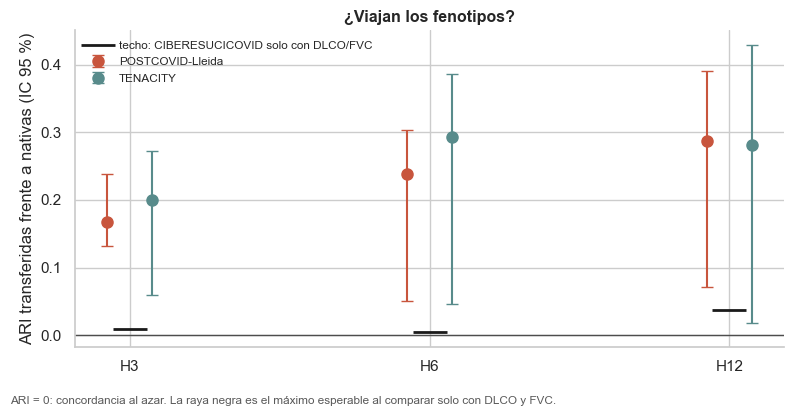

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
for i, rep in enumerate(FC["replica"]):
    xs, ys, lo, hi = [], [], [], []
    for j, h in enumerate(HORIZONTES):
        out = resultados[h]["replicas"].get(rep)
        if out is None:
            continue
        xs.append(j + (i - 0.5) * 0.15); ys.append(out["ari"])
        lo.append(out["ari"] - out["ari_ic"][0]); hi.append(out["ari_ic"][1] - out["ari"])
    ax.errorbar(xs, ys, yerr=[lo, hi], fmt="o", ms=8, capsize=4, color=COLOR[rep], label=ETQ[rep])
ax.plot(range(len(HORIZONTES)), [resultados[h]["ari_solo_compartidas"] for h in HORIZONTES], "k_", ms=25, mew=2,
        label=f"techo: {DESC} solo con DLCO/FVC")
ax.axhline(0, color="0.3", lw=1); ax.set_xticks(range(len(HORIZONTES)), HORIZONTES)
ax.set_ylabel("ARI transferidas frente a nativas (IC 95 %)"); ax.set_title("¿Viajan los fenotipos?")
ax.legend(frameon=False, fontsize=8.5)
nota(fig, "ARI = 0: concordancia al azar. La raya negra es el máximo esperable al comparar solo con DLCO y FVC.")
plt.tight_layout(); guardar(fig, "03_replicacion_ari"); plt.show()

### 6.3 Los fenotipos de CIBERESUCICOVID descritos en Lleida y TENACITY

Los pacientes de Lleida y TENACITY se asignan al fenotipo más cercano (con DLCO y FVC). Después se describen con lo que CIBERESUCICOVID no recoge: ansiedad y depresión (HADS), disnea (mMRC), prueba de marcha (PM6M), astenia y fatiga muscular. Así se aprovecha la información multidominio sin usarla para definir.

In [14]:
for h, r in resultados.items():
    bloques = {ETQ[DESC]: fichas[(h, DESC)]}
    for rep, out in r["replicas"].items():
        fichas[(h, rep)] = ficha(h, rep, out["datos"], out["transferidas"], r["k"])
        bloques[ETQ[rep]] = fichas[(h, rep)]
    print(f"\n=== {h} ===")
    display(pd.concat(bloques, axis=1).dropna(how="all"))
pd.concat({f"{h}|{c}": f for (h, c), f in fichas.items()}, names=["horizonte|cohorte", "variable"]).to_csv(TAB / "03_fichas.csv")


=== H3 ===


CIBERESUCICOVID               POSTCOVID-Lleida               TENACITY              
                                                    F1     F2     F3               F1     F2     F3       F1     F2     F3
N                                                255.0  362.0  296.0            164.0  105.0  195.0     70.0   31.0   53.0
Edad ≥ 65 (%)                                     29.8   31.8   31.1             31.1   34.6   36.9     41.0    NaN   38.6
Mujeres (%)                                       17.7   34.0   30.7             37.5   25.2   28.4     38.7   50.0   34.8
Estancia (mediana, días)                          21.0   27.0   30.0             14.0   15.0   20.5     20.5   14.0   24.0
ingreso_uci (%)                                  100.0  100.0  100.0             78.7   82.9   73.2    100.0  100.0  100.0
traqueo (%)                                       22.4   32.3   37.3             12.1   15.1   20.6      NaN    NaN    NaN
hta (%)                                           40.8   45.6   43.6             46.2   39.6   51.1     37.1   38.7   58.5
diabetes (%)                                      15.7   18.0   11.5             19.1   17.8   25.3     18.6    NaN   37.7
epoc (%)                                           3.9    6.4    NaN              NaN    NaN    8.4     15.7    NaN   24.5
card_cronica (%)                                  11.8   10.2    9.5              NaN    NaN    6.8      NaN    NaN   24.5
renal_cronica (%)                                  NaN    5.2    4.7              6.3    NaN    NaN      NaN    NaN    NaN
reingreso (% sí / alterado)                        5.1    4.1    NaN              NaN    NaN    NaN      NaN    NaN    NaN
urgencias (% sí / alterado)                       14.5   17.1   15.0              NaN    NaN    NaN      NaN    NaN    NaN
compl_cardiovascular (% sí / alterado)             NaN    4.4    NaN              NaN    NaN    NaN      NaN    NaN    NaN
compl_infecciosa (% sí / alterado)                 NaN    3.9    NaN              NaN    NaN    NaN      NaN    NaN    NaN
tac_normalizado (% sí / alterado)                 24.5   15.7   11.4              NaN    NaN    NaN      NaN    NaN    NaN
tac_infiltrados (% sí / alterado)                 33.6   23.5   24.8              NaN    NaN    NaN      NaN    NaN    NaN
tac_epid (% sí / alterado)                         NaN   11.4    8.1              NaN    NaN    NaN      NaN    NaN    NaN
tractos_fibrosos (% sí / alterado)                20.0   25.3   20.8              NaN    NaN    NaN      NaN    NaN    NaN
fev1 (% sí / alterado)                            16.2   31.8   30.7             32.9    NaN   47.2     42.9    NaN   73.6
hads_a (% sí / alterado)                           NaN    NaN    NaN             23.2   11.6   16.9     18.2    NaN    NaN
hads_d (% sí / alterado)                           NaN    NaN    NaN             13.9    NaN   14.2     18.2    NaN    NaN
mmrc (% sí / alterado)                             NaN    NaN    NaN             18.1   12.0   30.4     19.7    NaN   21.3
pm6m (% sí / alterado)                             NaN    NaN    NaN             28.3   27.1   42.7     41.7   37.0   59.1
astenia (% sí / alterado)                          NaN    NaN    NaN              NaN    NaN    NaN     25.0    NaN   30.6
fatiga_muscular (% sí / alterado)                  NaN    NaN    NaN             22.8   22.8   21.5      NaN    NaN    NaN


=== H6 ===


CIBERESUCICOVID               POSTCOVID-Lleida              TENACITY              
                                                    F1     F2     F3               F1    F2     F3       F1     F2     F3
N                                                272.0  289.0  238.0            133.0  57.0  194.0     27.0   12.0   21.0
Edad ≥ 65 (%)                                     33.1   38.1   35.7             46.5  45.6   33.9      NaN    NaN    NaN
Mujeres (%)                                       23.2   38.1   26.9             31.0  32.1   27.9      NaN    NaN    NaN
Estancia (mediana, días)                          25.0   31.0   37.0             17.5  15.0   18.0     22.0   17.0   25.0
ingreso_uci (%)                                  100.0  100.0  100.0             71.4  66.7   78.9    100.0  100.0  100.0
traqueo (%)                                       25.5   34.3   46.2             22.8   NaN   23.3      NaN    NaN    NaN
hta (%)                                           38.2   47.8   47.9             53.9  51.9   46.0     55.6    NaN    NaN
diabetes (%)                                      17.3   23.9   20.6             23.4   NaN   22.2      NaN    NaN    NaN
epoc (%)                                           5.9    4.2    NaN              NaN   NaN    NaN      NaN    0.0    NaN
card_cronica (%)                                   9.6   10.7   12.6              NaN   NaN    5.3      NaN    NaN    NaN
renal_cronica (%)                                  4.0    5.5    5.5              NaN   NaN    6.9      NaN    0.0    NaN
reingreso (% sí / alterado)                        5.2    8.7    6.7              NaN   NaN    NaN      NaN    NaN    NaN
urgencias (% sí / alterado)                       20.3   26.0   26.9              NaN   NaN    NaN      NaN    NaN    NaN
compl_cardiovascular (% sí / alterado)             NaN    7.3    4.6              NaN   NaN    NaN      NaN    NaN    NaN
compl_infecciosa (% sí / alterado)                 5.9    6.9    6.3              NaN   NaN    NaN      NaN    NaN    NaN
tac_normalizado (% sí / alterado)                 26.3   13.1   18.0              NaN   NaN    NaN      NaN    NaN    NaN
tac_infiltrados (% sí / alterado)                 30.4   33.3   36.0              NaN   NaN    NaN      NaN    NaN    NaN
tac_epid (% sí / alterado)                         NaN    8.2   11.2              NaN   NaN    NaN      NaN    NaN    NaN
tractos_fibrosos (% sí / alterado)                25.1   25.7   33.5              NaN   NaN    NaN      NaN    NaN    NaN
fev1 (% sí / alterado)                            14.2   21.1   21.6             18.0   0.0   39.2     48.1    0.0   52.4
hads_a (% sí / alterado)                           NaN    NaN    NaN             11.9   NaN   19.8      NaN    NaN    NaN
hads_d (% sí / alterado)                           NaN    NaN    NaN             10.3   0.0   13.4      NaN    NaN    NaN
mmrc (% sí / alterado)                             NaN    NaN    NaN             18.9   NaN   27.7      NaN    NaN    NaN
pm6m (% sí / alterado)                             NaN    NaN    NaN             31.8  22.8   23.8     53.8    NaN   52.6
astenia (% sí / alterado)                          NaN    NaN    NaN              NaN   0.0    NaN      NaN    NaN    NaN
fatiga_muscular (% sí / alterado)                  NaN    NaN    NaN             22.0   NaN   21.3      NaN    NaN    NaN


=== H12 ===


CIBERESUCICOVID               POSTCOVID-Lleida              TENACITY              
                                                    F1     F2     F3               F1    F2     F3       F1     F2     F3
N                                                194.0  192.0  180.0             93.0  74.0  134.0     17.0   14.0   35.0
Edad ≥ 65 (%)                                     36.6   38.0   41.1             42.4  65.8   31.6      NaN    NaN   34.5
Mujeres (%)                                       17.5   42.2   25.0             31.5  29.2   23.3      NaN    NaN   34.5
Estancia (mediana, días)                          26.0   31.0   37.5             17.0  18.0   20.0     24.0   17.0   19.0
ingreso_uci (%)                                  100.0   99.5  100.0             81.7  77.0   76.1    100.0  100.0  100.0
traqueo (%)                                       25.4   34.9   46.4             17.8  20.4   23.8      NaN    NaN    NaN
hta (%)                                           40.2   49.0   52.2             47.8  57.1   50.8      NaN    NaN   48.6
diabetes (%)                                      14.9   21.9   20.0             22.2  22.9   23.5      NaN    NaN   37.1
epoc (%)                                           NaN    5.7    6.7              NaN   NaN    NaN      NaN    0.0    NaN
card_cronica (%)                                  10.3    8.3   13.3              NaN   NaN    NaN      NaN    0.0    NaN
renal_cronica (%)                                  NaN    6.8    6.7              NaN   NaN    8.3      NaN    NaN    NaN
reingreso (% sí / alterado)                       11.4    9.9   10.0              NaN   NaN    NaN      NaN    NaN    NaN
urgencias (% sí / alterado)                       29.0   31.2   31.1              NaN   NaN    NaN      NaN    NaN    NaN
compl_cardiovascular (% sí / alterado)             NaN    7.8    NaN              NaN   NaN    NaN      NaN    NaN    NaN
compl_infecciosa (% sí / alterado)                 7.0    7.3    NaN              NaN   NaN    NaN      NaN    NaN    NaN
tac_normalizado (% sí / alterado)                 31.5   13.2   25.6              NaN   NaN    NaN      NaN    NaN    NaN
tac_infiltrados (% sí / alterado)                 33.9   43.1   45.0              NaN   NaN    NaN      NaN    NaN    NaN
tac_epid (% sí / alterado)                         NaN    8.3   11.6              NaN   NaN    NaN      NaN    NaN    NaN
tractos_fibrosos (% sí / alterado)                26.8   34.0   44.2              NaN   NaN    NaN      NaN    NaN    NaN
fev1 (% sí / alterado)                            15.1   20.5   23.6              NaN   NaN   50.7      NaN    NaN   80.0
hads_a (% sí / alterado)                           NaN    NaN    NaN             11.8   NaN    9.7      0.0    NaN    NaN
hads_d (% sí / alterado)                           NaN    NaN    NaN              NaN   NaN    9.7      NaN    NaN    NaN
mmrc (% sí / alterado)                             NaN    NaN    NaN             15.4   NaN   22.0      NaN    NaN    NaN
pm6m (% sí / alterado)                             NaN    NaN    NaN             21.7  17.8   25.4      NaN    NaN   45.2
astenia (% sí / alterado)                          NaN    NaN    NaN              NaN   0.0    NaN      0.0    NaN    NaN
fatiga_muscular (% sí / alterado)                  NaN    NaN    NaN             18.9   NaN   25.8      NaN    NaN    NaN

## 7 · Comparación entre horizontes

### 7.1 Pasaporte conjunto

In [15]:
pasaporte = pd.DataFrame([{
    "horizonte": h, "N": len(r["desc"]), "k": r["k"], "estructura": "sí" if r["estructura"] else "no",
    "silueta − nula": round(r["silueta"] - r["nulo"].set_index("k").loc[r["k"], "nulo_media"], 3),
    "Jaccard estabilidad (mín)": round(r["estab"]["jaccard_medio"].min(), 2),
    "ARI entre centros (mediana)": round(r["centros"]["ari"].median(), 2) if len(r["centros"]) else np.nan,
    "ARI solo DLCO/FVC": round(r["ari_solo_compartidas"], 2),
    **{f"ARI {ETQ[rep]}": f"{o['ari']:.2f} [{o['ari_ic'][0]:.2f}, {o['ari_ic'][1]:.2f}]" for rep, o in r["replicas"].items()},
} for h, r in resultados.items()]).set_index("horizonte")
pasaporte.to_csv(TAB / "03_pasaporte.csv")
pasaporte

,N,k,estructura,silueta − nula,Jaccard estabilidad (mín),ARI entre centros (mediana),ARI solo DLCO/FVC,ARI POSTCOVID-Lleida,ARI TENACITY
horizonte,,,,,,,,,
H3,913,3,sí,0.059,0.98,1.0,0.01,"0.17 [0.13, 0.24]","0.20 [0.06, 0.27]"
H6,799,3,sí,0.141,1.00,1.0,0.00,"0.24 [0.05, 0.30]","0.29 [0.05, 0.39]"
H12,566,3,sí,0.130,0.62,1.0,0.04,"0.29 [0.07, 0.39]","0.28 [0.02, 0.43]"


### 7.2 Transiciones entre horizontes

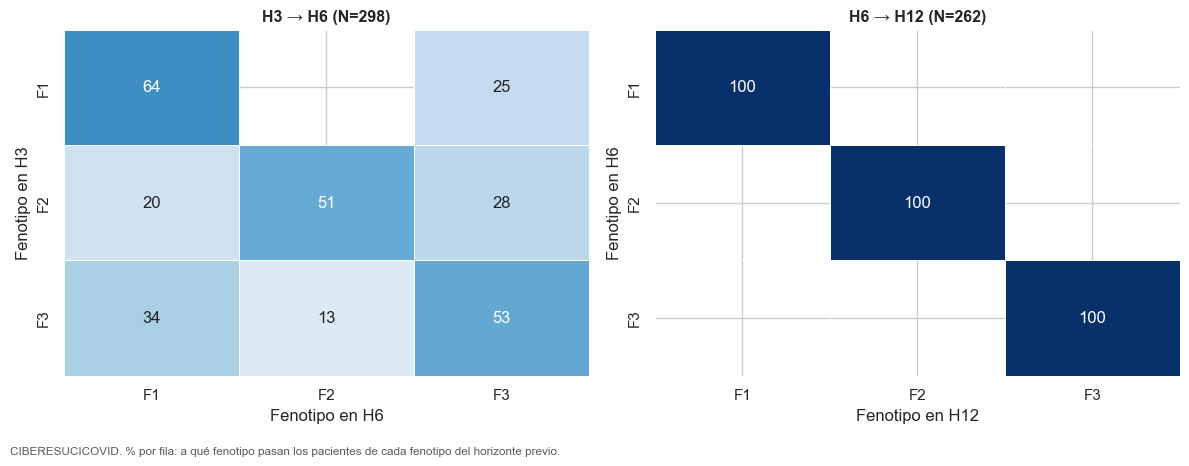

,pacientes comunes,ARI
transición,,
H3 → H6,298,0.11
H6 → H12,262,1.00


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
filas = []
for ax, (h1, h2) in zip(axes, [("H3", "H6"), ("H6", "H12")]):
    r1, r2 = resultados[h1], resultados[h2]
    e1 = pd.Series([nombre_f(c) for c in r1["lab"]], index=r1["desc"].index)
    e2 = pd.Series([nombre_f(c) for c in r2["lab"]], index=r2["desc"].index)
    tabla, ari, n = P.transiciones(e1, e2)
    filas.append({"transición": f"{h1} → {h2}", "pacientes comunes": n, "ARI": round(ari, 2)})
    if n:
        pct = tabla.div(tabla.sum(axis=1), axis=0) * 100
        anot = pct.round(0).astype(int).astype(str).mask(tabla < N_MIN, "<10")
        sns.heatmap(pct.mask(tabla < N_MIN), annot=anot.values, fmt="", cmap="Blues", vmin=0, vmax=100, cbar=False, ax=ax, linewidths=0.5)
    ax.set_xlabel(f"Fenotipo en {h2}"); ax.set_ylabel(f"Fenotipo en {h1}"); ax.set_title(f"{h1} → {h2} (N={n})")
nota(fig, f"{DESC}. % por fila: a qué fenotipo pasan los pacientes de cada fenotipo del horizonte previo.")
plt.tight_layout(); guardar(fig, "03_transiciones"); plt.show()
pd.DataFrame(filas).set_index("transición")

### 7.3 ¿El fenotipo a 3 meses anticipa el año?

Para los pacientes fenotipados en H3 se calcula el % con DLCO < 80 % a los 12 meses y con algún reingreso o visita a urgencias hasta los 12 meses. Se hace en CIBERESUCICOVID y, con las etiquetas transferidas, en Lleida y TENACITY (solo la DLCO).

In [17]:
r = resultados["H3"]
grupos = {DESC: (r["desc"], r["lab"])}
grupos.update({rep: (o["datos"], o["transferidas"]) for rep, o in r["replicas"].items()})
desenlaces = {"DLCO < 80 % a 12 m": ("dlco", ["A1"], "ultima"),
              "Reingreso hasta 12 m": ("reingreso", ["M3", "M6", "A1"], "alguna"),
              "Urgencias hasta 12 m": ("urgencias", ["M3", "M6", "A1"], "alguna")}
filas, pruebas = [], []
for coh, (datos, lab) in grupos.items():
    for nombre, (v, visitas, regla) in desenlaces.items():
        if coh not in cfg["variables_visita"][v]:
            continue
        y = F.estado_hasta(medidas, cfg, coh, datos.index, v, visitas, regla)
        ok = y.notna().values
        if ok.sum() < N_MIN:
            continue
        ct = pd.crosstab(lab[ok], y.values[ok])
        if ct.shape[1] == 2 and (ct.values > 0).all():
            pruebas.append({"cohorte": ETQ[coh], "desenlace": nombre, "N": int(ok.sum()),
                            "p (χ²)": f"{stats.chi2_contingency(ct)[1]:.2g}"})
        for c in range(r["k"]):
            s = y.values[ok & (lab == c)]
            k = int(np.nansum(s))
            if len(s) < N_MIN or 0 < k < N_MIN:
                continue
            lo, hi = ic_wilson(k, len(s))
            filas.append({"cohorte": ETQ[coh], "desenlace": nombre, "fenotipo H3": nombre_f(c), "N": len(s),
                          "%": round(100 * k / len(s), 1), "IC95": f"{lo:.0f}–{hi:.0f}"})
pronostico = pd.DataFrame(filas)
pronostico.to_csv(TAB / "03_pronostico_h3.csv", index=False)
display(pd.DataFrame(pruebas).set_index(["cohorte", "desenlace"]) if pruebas else "sin pruebas evaluables")
pronostico.set_index(["cohorte", "desenlace", "fenotipo H3"])

N   p (χ²)
cohorte          desenlace                         
CIBERESUCICOVID  DLCO < 80 % a 12 m    220     0.44
                 Reingreso hasta 12 m  912     0.83
                 Urgencias hasta 12 m  912     0.44
POSTCOVID-Lleida DLCO < 80 % a 12 m    217  3.4e-05
TENACITY         DLCO < 80 % a 12 m     51     0.52

N     %   IC95
cohorte          desenlace            fenotipo H3                  
CIBERESUCICOVID  DLCO < 80 % a 12 m   F1            58  62.1  49–73
                                      F2            92  63.0  53–72
                                      F3            70  71.4  60–81
                 Reingreso hasta 12 m F1           255   8.6   6–13
                                      F2           362   9.4   7–13
                                      F3           295  10.2   7–14
                 Urgencias hasta 12 m F1           255  25.1  20–31
                                      F2           362  29.3  25–34
                                      F3           295  29.5  25–35
POSTCOVID-Lleida DLCO < 80 % a 12 m   F1            67  37.3  27–49
                                      F2            45  48.9  35–63
                                      F3           105  71.4  62–79

## 8 · Sensibilidad

Se repite cada horizonte cambiando una sola cosa, con menos permutaciones y remuestreos para no alargar la ejecución:
- **k = 3 fijo**;
- **solo función** (DLCO y FVC): ¿hay fenotipos respiratorios sin síntomas?;
- **solo síntomas**;
- **sin variables de cambio**;
- **`cmd99`** en lugar de `cmd50`.

In [18]:
cmd99 = set(pacientes.loc[pacientes["cmd99"], "subject_id"])
rapido = dict(n_perm=20, n_boot=50, replicar=False)
filas = []
for h, base in resultados.items():
    cols = base["cols"]
    escenarios = {"principal": None,
                  f"k = {FC['k_comparacion']} fijo": dict(k_forzado=FC["k_comparacion"]),
                  "solo función": dict(columnas=[c for c in cols if c.rsplit("_", 1)[0] in FC["dominios"]["funcion"]]),
                  "solo síntomas": dict(columnas=[c for c in cols if c.rsplit("_", 1)[0] in FC["dominios"]["sintomas"]]),
                  "cmd99": dict(filtro=lambda d: d.index.isin(cmd99))}
    if any(c.endswith("_cambio") for c in cols):
        escenarios["sin cambios"] = dict(columnas=[c for c in cols if not c.endswith("_cambio")])
    for nombre, kw in escenarios.items():
        r = base if kw is None else ejecutar(h, **kw, **rapido)
        ari_vs_principal = np.nan
        if kw is not None:
            comunes = r["desc"].index.intersection(base["desc"].index)
            a = pd.Series(base["lab"], index=base["desc"].index).loc[comunes]
            b = pd.Series(r["lab"], index=r["desc"].index).loc[comunes]
            ari_vs_principal = adjusted_rand_score(a, b)
        filas.append({"horizonte": h, "escenario": nombre, "N": len(r["desc"]), "k": r["k"],
                      "estructura": "sí" if r["estructura"] else "no", "silueta": round(r["silueta"], 2),
                      "Jaccard estab. (media)": round(r["estab"]["jaccard_medio"].mean(), 2),
                      "ARI frente al principal": round(ari_vs_principal, 2)})
sensibilidad = pd.DataFrame(filas).set_index(["horizonte", "escenario"])
sensibilidad.to_csv(TAB / "03_sensibilidad.csv")
privacidad.suprimir_celdas(sensibilidad, N_MIN, ["N"])

N  k estructura  silueta  Jaccard estab. (media)  ARI frente al principal
horizonte escenario                                                                                 
H3        principal      913  3         sí     0.58                    0.99                      NaN
          k = 3 fijo     913  3         sí     0.58                    0.99                     1.00
          solo función   913  2         sí     0.40                    0.93                     0.01
          solo síntomas  913  2         no     0.51                    0.86                     0.50
          cmd99          909  3         sí     0.58                    0.98                     1.00
H6        principal      799  3         sí     0.50                    1.00                      NaN
          k = 3 fijo     799  3         sí     0.50                    1.00                     1.00
          solo función   799  5         sí     0.24                    0.72                     0.01
          solo síntomas  799  2         no     0.44                    0.94                     0.57
          cmd99          797  3         sí     0.50                    1.00                     1.00
          sin cambios    799  3         sí     0.45                    0.99                     0.99
H12       principal      566  3         sí     0.37                    0.68                      NaN
          k = 3 fijo     566  3         sí     0.37                    0.64                     1.00
          solo función   566  2         sí     0.33                    0.82                     0.02
          solo síntomas  541  2         no     0.41                    0.87                     0.50
          cmd99          564  5         sí     0.32                    0.61                     0.66
          sin cambios    566  2         sí     0.45                    0.71                     0.12

## 9 · Guardar las etiquetas

In [19]:
filas = []
for h, r in resultados.items():
    D_med = F.gower(r["X"], r["X"][r["med"]], r["R"], r["w"], r["cat"])
    filas.append(pd.DataFrame({"subject_id": r["desc"].index, "horizonte": h, "cohorte_analisis": DESC,
                               "fenotipo": [nombre_f(c) for c in r["lab"]], "tipo": "descubrimiento",
                               "distancia_medoide": D_med[np.arange(len(r["lab"])), r["lab"]]}))
    for rep, out in r["replicas"].items():
        Xr = out["datos"].reindex(columns=r["cols"]).to_numpy(float)
        D_r = F.gower(Xr, r["X"][r["med"]], r["R"], r["w"], r["cat"])
        for tipo, lab in [("transferida", out["transferidas"]), ("nativa", out["nativas"])]:
            filas.append(pd.DataFrame({"subject_id": out["datos"].index, "horizonte": h, "cohorte_analisis": rep,
                                       "fenotipo": [nombre_f(c) for c in lab], "tipo": tipo,
                                       "distancia_medoide": D_r[np.arange(len(lab)), lab]}))
fenotipos = pd.concat(filas, ignore_index=True)
fenotipos.to_parquet(DATOS / "fenotipos.parquet", index=False)
print(f"Guardado {DATOS.name}/fenotipos.parquet: {len(fenotipos):,} filas")
privacidad.suprimir_celdas(fenotipos.groupby(["horizonte", "cohorte_analisis", "tipo"]).size().unstack(fill_value=0),
                           N_MIN, ["descubrimiento", "transferida", "nativa"])

Guardado Datos limpios/fenotipos.parquet: 5,136 filas


tipo                        descubrimiento  nativa  transferida
horizonte cohorte_analisis                                     
H12       CIBERESUCICOVID              566       0            0
          POSTCOVID_LLEIDA               0     301          301
          TENACITY                       0      66           66
H3        CIBERESUCICOVID              913       0            0
          POSTCOVID_LLEIDA               0     464          464
          TENACITY                       0     154          154
H6        CIBERESUCICOVID              799       0            0
          POSTCOVID_LLEIDA               0     384          384
          TENACITY                       0      60           60

## 10 · Resumen

**Resultados (ejecución con semilla 2026 y regla R14 de fatiga deducida; ver §3–§8).**

1. **Hay estructura en los tres horizontes, pero es modesta.** k = 3 en H3, H6 y H12. La silueta supera al p95 del nulo, con un margen pequeño en H3 (+0,06) y moderado en H6 y H12 (+0,13 a +0,14). Antes de la regla R14 el margen parecía mayor (+0,25): parte de la "estructura" era el patrón de fatiga sin dato. La estabilidad bootstrap es casi perfecta en H3 y H6 (Jaccard ≥ 0,98) y de patrón en H12 (0,62–0,72). La partición no cambia al dejar fuera un centro (ARI = 1); con `cmd99` no cambia en H3 ni en H6, pero en H12 sí (k = 5, ARI 0,66).
2. **Los fenotipos los definen los síntomas, no la función.** Sus nombres son borradores para que los valide el equipo:
   - **F1 · "resolución completa":** sin síntomas, la mejor función (DLCO mediana 79 % a 3 meses) y más TAC normalizados. En H6, F1 incluye a quien se resuelve entre los 3 y los 6 meses.
   - **F2 · "persistente con fatiga":** resolución parcial con astenia/fatiga, más mujeres y función intermedia.
   - **F3 · "persistente sin fatiga":** resolución parcial sin fatiga, la peor función, estancia más larga, más traqueotomías y más tractos fibrosos en el TAC.

   La función pulmonar se reparte como un **gradiente** entre los tres, no los separa. Con solo DLCO y FVC se reconocen mal (ARI ≈ 0, §6.1). La sensibilidad "solo función" encuentra otra partición, también con estructura, sin relación con la principal (ARI 0,01–0,02).
3. **H6 → H12 no cambia** (ARI 1,0), porque a los 12 meses no hay síntomas nuevos y los de 3 y 6 meses dominan. H3 → H6 sí cambia (ARI 0,11): los síntomas evolucionan entre los 3 y los 6 meses.
4. **La replicación es débil, como era de esperar.** Lleida y TENACITY solo comparten DLCO y FVC, y los fenotipos son de síntomas: ARI 0,17–0,29, con Jaccard por par mayoritariamente < 0,5. Los perfiles respiratorios de los transferidos se parecen (|d| < 0,5 en el 42–83 % de las comparaciones). **No se puede afirmar que los fenotipos "viajen"**: se transfiere su gradiente respiratorio, no su componente sintomático.
5. **El fenotipo a 3 meses no anticipa el año en CIBERESUCICOVID.** No discrimina la DLCO < 80 % a 12 meses (p = 0,44), los reingresos (p = 0,83) ni las urgencias (p = 0,44). En Lleida, la asignación transferida (por función) sí se asocia con la DLCO al año: 37 %, 49 % y 71 % (p < 0,001).

**Implicaciones**
- Los fenotipos de CIBERESUCICOVID son **sintomáticos, estables a 3 y 6 meses y poco transferibles**. Hay tres caminos, y la decisión es del equipo:
  - presentarlos como fenotipos internos de CIBERESUCICOVID;
  - usar como principal la partición "solo función", que se puede comparar con Lleida y TENACITY;
  - definir un fenotipo **combinado** con un síntoma armonizado entre cohortes.
- Las variables binarias (fatiga, resolución) tienden a dominar Gower y la silueta alta lo refleja: la ventaja real frente al nulo es la columna "silueta − nula" del pasaporte (§7.1).

**Limitaciones:**
- **Síntomas binarios.** Fatiga y resolución tienen pocas categorías: en Gower pesan como diferencias "todo o nada", y pueden dominar la partición. Por eso existe la sensibilidad "solo función" y "solo síntomas" (§8).
- **Comparación parcial.** Lleida y TENACITY solo comparten DLCO y FVC. La comparación mide la parte respiratoria del fenotipo, con el techo de §6.1.
- **A 12 meses no hay síntomas nuevos** en CIBERESUCICOVID: H12 combina la función a 12 meses con los síntomas a 3 y 6 meses.
- **Abandono informativo** (notebook 01, §8): H12 sobrerrepresenta a quien sigue en seguimiento.
- **No se imputa:** quien tiene pocas medidas pesa con menos información.